# Automation of CSV Cleaning

Considerations:

1. we only need tripinfo.csv, it's got all the relvant information we need
2. I'll be adding some extra columns, if we don't need them we just ignore them, but they might come in handy
3. It's very important that the experimental setup of each of the experiments is annotated (what each flow represents, for example explain that flow0 is private or public, etc) in case the number of flows or identifiers changes throughout implementations


Column names and meanings:

1. **`departDelay (simulation seconds)`**: The time the vehicle had to wait before it could start his journey
2. **`waitingTime (s, assume simulation seconds aswell)`**: The time in which the vehicle speed was below or equal 0.1 m/s (scheduled stops do not count)
3. **`waitingCount`**: The number of times the vehicle speed went below or equal 0.1 m/s
4. **`timeLoss`**: the time lost due to traveling at speed below the maximum speed in that stage. For a <ride> this is the timeLoss of the vehicle during the ride
5. **`CO2_abs (milligrams)`**: The complete amount of CO2 emitted by the vehicle during the trip

Aggregation rationale:

1. Vehicle id's (flow0_0) will repeat, and we'll consider that the same id one day represents the same car in the next day (meaning they have the same departure time, but **there might be cases where the total number of cars is not the same, due to the policy acceptance!**) to check evolution of the users (if match between days is possible) 
2. Special columns day and sim will be created in each aggregated csv to properly identify evolution
3. The dataset is guaranteed to be ordered by simulation and day of simulation, due to the way I designed the xmls to be saved and converted to csv, so all that is left to do is order each csv by tripinfo_id and then always aggregate on the bottom
4. Unlike the `emissions` dataframe, `tripinfo` already has the aggregated data for all observations, for the entire simulation, removing the need to aggregate using means or sums 

Final structure:

<center>

|tripinfo_id|tripinfo_vtype|day|sim|CO2_abs|departDelay|waitingTime|waitingCount|timeLoss|
|-----------|--------------|---|---|-------|-----------|-----------|------------|--------|
|...........|..............|...|...|.......|...........|...........|............|........|

</center>



## Imports

In [124]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import re


## Building the Dataframe

It all starts with choosing the respective policy folder and getting each file name in alphanumeric order: 

In [125]:
policy_name = str(input())
POLICY_FOLDER = "../sumo_runs/" + policy_name + "/"

# Gets every file name in POLICY_FOLDER in order
filenames = sorted(
    (POLICY_FOLDER + f) for f in os.listdir(POLICY_FOLDER)
    if os.path.isfile(os.path.join(POLICY_FOLDER, f))
)

print(filenames)

['../sumo_runs/cleanup_test/tripinfo_sim1_day1_policy_bus_subsidy.csv', '../sumo_runs/cleanup_test/tripinfo_sim1_day2_policy_bus_subsidy.csv', '../sumo_runs/cleanup_test/tripinfo_sim1_day3_policy_bus_subsidy.csv', '../sumo_runs/cleanup_test/tripinfo_sim1_day4_policy_bus_subsidy.csv', '../sumo_runs/cleanup_test/tripinfo_sim1_day5_policy_bus_subsidy.csv', '../sumo_runs/cleanup_test/tripinfo_sim1_day6_policy_bus_subsidy.csv', '../sumo_runs/cleanup_test/tripinfo_sim1_day7_policy_bus_subsidy.csv']


In [126]:
first_df = pd.read_csv(filenames[0], sep=";")

first_df.head()

,tripinfo_arrival,tripinfo_arrivalLane,tripinfo_arrivalPos,tripinfo_arrivalSpeed,tripinfo_depart,tripinfo_departDelay,tripinfo_departLane,tripinfo_departPos,tripinfo_departSpeed,tripinfo_devices,...,tripinfo_vaporized,tripinfo_waitingCount,tripinfo_waitingTime,emissions_CO2_abs,emissions_CO_abs,emissions_HC_abs,emissions_NOx_abs,emissions_PMx_abs,emissions_electricity_abs,emissions_fuel_abs
0,59.0,E2D2_0,85.6,13.64,0.0,0.00,A4B4_0,4.6,0.0,tripinfo_flow_0.0 emissions_flow_0.0,...,NaN,0,0.0,172724.53,1854.83,12.38,68.63,2.90,0.0,55107.47
1,77.0,C0B0_0,85.6,9.62,0.0,0.00,A2A3_0,7.6,0.0,tripinfo_flow_1.0 emissions_flow_1.0,...,NaN,0,0.0,158578.22,2226.91,13.94,63.64,2.83,0.0,50592.66
2,523.0,E2D2_0,85.6,13.78,463.0,0.97,A4B4_0,4.6,0.0,tripinfo_flow_0.1 emissions_flow_0.1,...,NaN,0,0.0,174620.26,1903.66,12.81,70.23,3.02,0.0,55711.93
3,984.0,E2D2_0,85.6,13.49,925.0,0.94,A4B4_0,4.6,0.0,tripinfo_flow_0.2 emissions_flow_0.2,...,NaN,0,0.0,170620.52,1826.64,12.36,68.77,2.94,0.0,54435.85
4,1448.0,E2D2_0,85.6,13.67,1387.0,0.91,A4B4_0,4.6,0.0,tripinfo_flow_0.3 emissions_flow_0.3,...,NaN,0,0.0,178136.53,1893.84,12.89,71.02,2.98,0.0,56834.01


In [127]:
first_df.columns

Index(['tripinfo_arrival', 'tripinfo_arrivalLane', 'tripinfo_arrivalPos',
       'tripinfo_arrivalSpeed', 'tripinfo_depart', 'tripinfo_departDelay',
       'tripinfo_departLane', 'tripinfo_departPos', 'tripinfo_departSpeed',
       'tripinfo_devices', 'tripinfo_duration', 'tripinfo_id',
       'tripinfo_rerouteNo', 'tripinfo_routeLength', 'tripinfo_speedFactor',
       'tripinfo_stopTime', 'tripinfo_timeLoss', 'tripinfo_vType',
       'tripinfo_vaporized', 'tripinfo_waitingCount', 'tripinfo_waitingTime',
       'emissions_CO2_abs', 'emissions_CO_abs', 'emissions_HC_abs',
       'emissions_NOx_abs', 'emissions_PMx_abs', 'emissions_electricity_abs',
       'emissions_fuel_abs'],
      dtype='object')

In [128]:
len(first_df)

202

In [129]:
len(first_df["tripinfo_id"].unique())

202

After getting every relevant `.csv`, `getClean` is combined with `orderSpawn` to initialize the global dataframe structure, starting from the first item in the folder:

In [130]:
def orderSpawn(df):
    # Extract flow number and car number
    df["flow_id"] = df["tripinfo_id"].str.extract(r"flow_(\d+)\.\d+").astype(int)
    df["car_num"] = df["tripinfo_id"].str.split(".", n=1).str[1].astype(int)

    # Sort by flow_id first, then by car_num
    df = df.sort_values(by=["flow_id", "car_num"], ascending=[True, True]).drop(columns=["car_num"])

    return df

In [131]:
def getClean(f):
    
    '''
        New Dataframe:
        - tripinfo_id : str
        - tripinfo_vType : str
        - day         : int
        - sim         : int
        - CO2_abs     : float
        - departDelay : float
        - waitingTime : float
        - waitingCount: int
        - timeLoss    : float
    '''
    
    # Read file
    df = pd.read_csv(f, sep=";")

    # Get day and simulation from file name
    match = re.search(r"sim(\d+)_day(\d+)", f)
    if match:
        sim = int(match.group(1))
        day = int(match.group(2))

    # Order: flow -> car
    df = orderSpawn(df)

    # Start clean dataframe (some column names are simplified)
    df_clean = pd.DataFrame()

    # Increasing unique ID
    df_clean["tripinfo_id"] = df["tripinfo_id"]
    df_clean["tripinfo_vType"] = df["tripinfo_vType"]

    # Increasing day and simulation
    df_clean["day"] = day
    df_clean["sim"] = sim 

    # Total daily CO2 emission in mg per car
    df_clean["CO2_abs"] = df["emissions_CO2_abs"]

    # Total daily departure delays, waiting times,
    # waiting counts and time losses
    df_clean["departDelay"] = df["tripinfo_departDelay"]
    df_clean["waitingTime"] = df["tripinfo_waitingTime"]
    df_clean["waitingCount"] = df["tripinfo_waitingCount"]
    df_clean["timeLoss"] = df["tripinfo_timeLoss"]

    return df_clean   


In [132]:
df = getClean(filenames[0])
df_global = df.copy()

In [133]:
df.head()

,tripinfo_id,tripinfo_vType,day,sim,CO2_abs,departDelay,waitingTime,waitingCount,timeLoss
0,flow_0.0,car,1,1,172724.53,0.00,0.0,0,9.71
2,flow_0.1,car,1,1,174620.26,0.97,0.0,0,10.38
3,flow_0.2,car,1,1,170620.52,0.94,0.0,0,9.77
4,flow_0.3,car,1,1,178136.53,0.91,0.0,0,10.51
5,flow_0.4,car,1,1,156768.11,0.88,0.0,0,11.02


Then, we iteratively apply `getClean` over each remaining file, and aggregating every new result to build the global dataframe:

In [134]:
for f in filenames[1:]: df_global = pd.concat([df_global, getClean(f)], ignore_index=True)

In [135]:
df_global.tail()

,tripinfo_id,tripinfo_vType,day,sim,CO2_abs,departDelay,waitingTime,waitingCount,timeLoss
1401,flow_1.142,bus,7,1,165024.50,0.08,0.0,0,10.66
1402,flow_1.143,bus,7,1,167979.22,0.32,0.0,0,10.23
1403,flow_1.144,bus,7,1,162959.34,0.56,0.0,0,8.97
1404,flow_1.145,bus,7,1,164020.45,0.80,0.0,0,9.99
1405,flow_1.146,bus,7,1,166165.33,0.04,0.0,0,11.23


Perfect! Now we can generate meaningful plots to show overall changes!

In [136]:
print(len(df_global))
print(len(df_global["tripinfo_id"].unique()))

1406
335


In [137]:
def spaghettiPlot(value, avg=False, by="day", df=df_global):
    # can show evolution by day or sim
    
    fig, ax = plt.subplots()

    # Spaghetti plot
    if not avg:
        # Plot individual trajectories
        for _, g in df.groupby("tripinfo_id"):
            ax.plot(
                g[by],
                g[value],
                color="tab:blue",
                alpha=0.3,
                linewidth=1
            )

        # Plot mean trajectory
        mean_by_day = df.groupby(by)[value].mean()

        ax.plot(
            mean_by_day.index,
            mean_by_day.values,
            color="blue",
            linewidth=3,
            label="Mean"
        )

    # Daily averages per vehicle type
    else:
        agg = (
            df
            .groupby([by, "tripinfo_vType"])[value]
            .mean()
            .reset_index()
        )

        # Plots each vehicle type separately
        for vtype, color in [("car", "red"), ("bus", "blue")]:
            g = agg[agg["tripinfo_vType"] == vtype]

            ax.plot(
                g[by],
                g[value],
                color=color,
                linewidth=3,
                label=vtype.capitalize()
            )

        # Plots overall daily average (all vehicle types)
        overall_avg = df.groupby(by)[value].mean()
        ax.plot(
            overall_avg.index,
            overall_avg.values,
            color="green",
            linewidth=3,
            linestyle="--",
            label="Overall Avg"
        )

        ax.legend()

    ax.set_xlabel(by)
    ax.set_ylabel(value)

    plt.show()


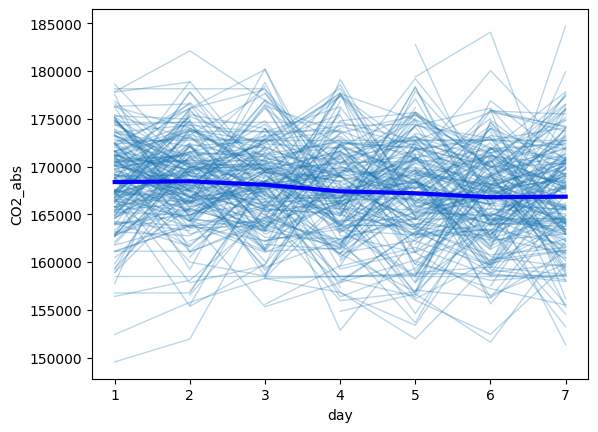

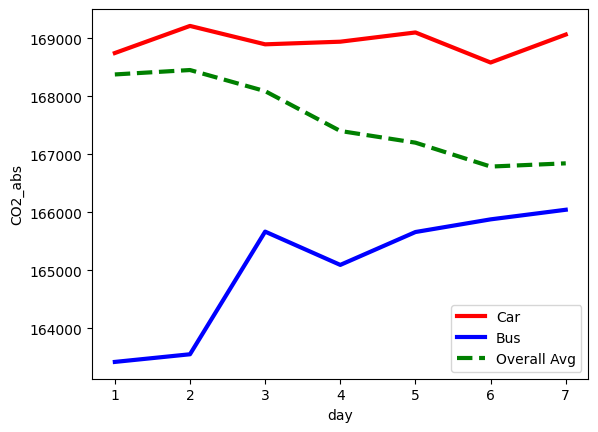

In [138]:
spaghettiPlot("CO2_abs")
spaghettiPlot("CO2_abs", True)

In [139]:
df_global.to_csv(policy_name+".csv", index=False)